Index dtype: datetime64[ns, UTC+01:00]


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.0001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


GP MAE: 79.01 MW
GP RMSE: 81.28 MW
Epoch 1/20, Loss: 0.2843
Epoch 2/20, Loss: 0.1591
Epoch 3/20, Loss: 0.1577
Epoch 4/20, Loss: 0.1493
Epoch 5/20, Loss: 0.1454
Epoch 6/20, Loss: 0.1437
Epoch 7/20, Loss: 0.1489
Epoch 8/20, Loss: 0.1426
Epoch 9/20, Loss: 0.1404
Epoch 10/20, Loss: 0.1397
Epoch 11/20, Loss: 0.1408
Epoch 12/20, Loss: 0.1379
Epoch 13/20, Loss: 0.1367
Epoch 14/20, Loss: 0.1369
Epoch 15/20, Loss: 0.1431
Epoch 16/20, Loss: 0.1351
Epoch 17/20, Loss: 0.1363
Epoch 18/20, Loss: 0.1351
Epoch 19/20, Loss: 0.1314
Epoch 20/20, Loss: 0.1327
Transformer MAE: 77.70 MW
Transformer RMSE: 101.42 MW


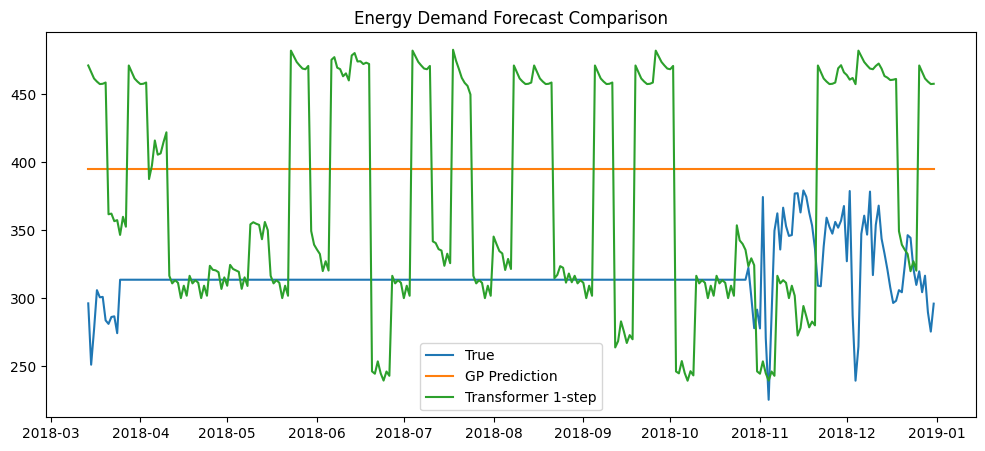

In [10]:
# energy_demand_forecasting.py
"""
Forecast energy demand time series using Gaussian Process and a Transformer model.
Dataset: energy_dataset.csv (ensure it is in the working directory or adjust path)
"""

# 1. IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# 2. LOAD & PREPROCESS DATA
# Read CSV using first column as datetime index
df = pd.read_csv(r'D:\Timeseries\TH3\energy_dataset.csv', index_col=0, parse_dates=True)

# Ensure index is DatetimeIndex
df.index = pd.to_datetime(df.index, errors='coerce')
df = df[df.index.notna()]
df.index.name = 'Datetime'
print('Index dtype:', df.index.dtype)

# Select the first numeric column for modeling
num_col = df.select_dtypes(include=[np.number]).columns[0]
series = df[num_col].resample('D').mean().ffill()

# 3. GAUSSIAN PROCESS REGRESSION
X = np.arange(len(series)).reshape(-1, 1)
y = series.values
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Broaden kernel bounds to avoid convergence warnings
gp_kernel = C(1.0, (1e-4, 1e4)) * RBF(length_scale=50, length_scale_bounds=(1e-4, 1e4))
gp = GaussianProcessRegressor(kernel=gp_kernel, normalize_y=True)

gp.fit(X_train, y_train)
y_pred_gp, y_std = gp.predict(X_test, return_std=True)

gp_mae = mean_absolute_error(y_test, y_pred_gp)
gp_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gp))
print(f"GP MAE: {gp_mae:.2f} MW")
print(f"GP RMSE: {gp_rmse:.2f} MW")

# 4. TRANSFORMER MODEL DEFINITION
class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_len=30, pred_len=7):
        X, Y = [], []
        for i in range(len(data) - seq_len - pred_len):
            X.append(data[i:i + seq_len])
            Y.append(data[i + seq_len:i + seq_len + pred_len])
        arrX = np.array(X)
        arrY = np.array(Y)
        self.X = torch.tensor(arrX, dtype=torch.float32)
        self.Y = torch.tensor(arrY, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

class TransformerModel(nn.Module):
    def __init__(self, input_size=1, d_model=64, nhead=4, num_layers=2,
                 dim_ff=128, pred_len=7, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.decoder = nn.Linear(d_model, pred_len)

    def forward(self, x):
        # x: [batch, seq_len]
        x = x.unsqueeze(-1)            # [batch, seq_len, 1]
        x = self.input_proj(x)         # [batch, seq_len, d_model]
        out = self.transformer(x)      # [batch, seq_len, d_model]
        out = out[:, -1, :]            # take the last time step [batch, d_model]
        out = self.decoder(out)        # [batch, pred_len]
        return out

# 5. PREPARE DATA FOR TRANSFORMER
scaler = StandardScaler()
series_scaled = scaler.fit_transform(series.values.reshape(-1,1)).flatten()
seq_len, pred_len = 30, 7
dataset = TimeSeriesDataset(series_scaled, seq_len=seq_len, pred_len=pred_len)

ntrain = int(len(dataset) * 0.8)
train_ds, test_ds = torch.utils.data.random_split(dataset, [ntrain, len(dataset) - ntrain])
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)

# 6. TRAIN TRANSFORMER
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TransformerModel(pred_len=pred_len).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
epochs = 20

for epoch in range(1, epochs+1):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

# 7. EVALUATE TRANSFORMER
model.eval()
all_preds, all_trues = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb).cpu().numpy()
        trues = yb.cpu().numpy()
        all_preds.append(preds)
        all_trues.append(trues)
all_preds = np.concatenate(all_preds, axis=0).flatten()
all_trues = np.concatenate(all_trues, axis=0).flatten()

# Inverse scale and align with y_test for 1-step forecasts
inv_preds = scaler.inverse_transform(all_preds.reshape(-1,1)).flatten()
inv_preds = inv_preds[:len(y_test)]

tr_mae_orig = mean_absolute_error(y_test, inv_preds)
tr_rmse_orig = np.sqrt(mean_squared_error(y_test, inv_preds))
print(f"Transformer MAE: {tr_mae_orig:.2f} MW")
print(f"Transformer RMSE: {tr_rmse_orig:.2f} MW")

# 8. PLOT COMPARISON
plt.figure(figsize=(12,5))
plt.plot(series.index[split:split+len(y_test)], y_test, label='True')
plt.plot(series.index[split:split+len(y_test)], y_pred_gp, label='GP Prediction')
plt.plot(series.index[split:split+len(y_test)], inv_preds, label='Transformer 1-step')
plt.legend()
plt.title('Energy Demand Forecast Comparison')
plt.show()